<a href="https://colab.research.google.com/github/magish-gautam/Magish-Concept-of-AI/blob/Workshop-2/Worksheet_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



===== IMDB NAIVE BAYES RESULTS =====
Accuracy: 0.8494
Precision: 0.8549326903757284
Recall: 0.8444135741218496
F1 Score: 0.8496405750798722
ROC-AUC: 0.912517937591323

Confusion Matrix:
 [[4239  722]
 [ 784 4255]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85      4961
           1       0.85      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



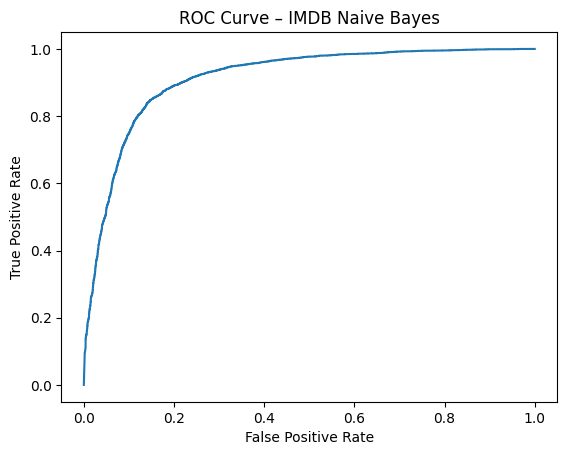

In [8]:
##IMDB##


import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

nltk.download('stopwords')

imdb = pd.read_csv("IMDB_Dataset.csv")
imdb['sentiment'] = imdb['sentiment'].map({'positive': 1, 'negative': 0})

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub('[^a-z]', ' ', text)
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

imdb['clean_review'] = imdb['review'].apply(preprocess)

X_train, X_test, y_train, y_test = train_test_split(
    imdb['clean_review'],
    imdb['sentiment'],
    test_size=0.2,
    random_state=42
)

vectorizer = CountVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)
y_prob = model.predict_proba(X_test_vec)[:, 1]

print("\n===== IMDB NAIVE BAYES RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – IMDB Naive Bayes")
plt.show()



Selected Top 5 Features:
['radius_se', 'radius_worst', 'texture_worst', 'area_worst', 'concave points_worst']


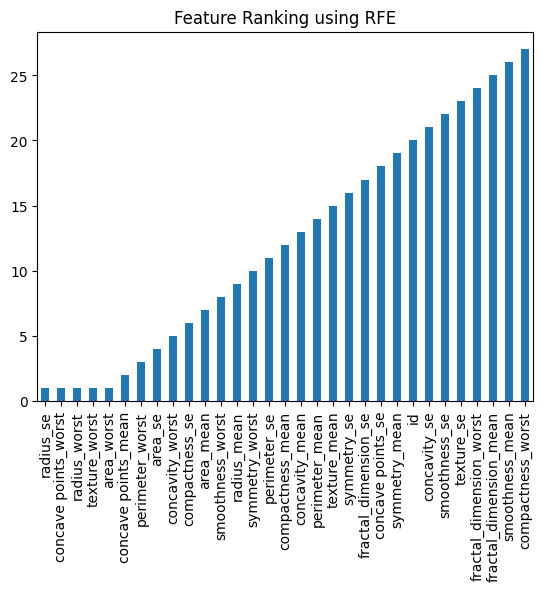


===== MODEL WITH SELECTED FEATURES =====
Accuracy: 0.9736842105263158
Precision: 0.9761904761904762
Recall: 0.9534883720930233
F1 Score: 0.9647058823529412
ROC-AUC: 0.9977071732721913

ROC-AUC (All Features): 0.99737962659679
ROC-AUC (Selected Features): 0.9977071732721913
Accuracy with Top 3 Features: 0.9649122807017544
Accuracy with Top 7 Features: 0.9736842105263158


In [14]:
# BREAST CANCER
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)


cancer = pd.read_csv("breast-cancer.csv")


X = cancer.drop('diagnosis', axis=1)
y = cancer['diagnosis']

le = LabelEncoder()
y = le.fit_transform(y)


scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

log_reg = LogisticRegression(max_iter=5000)
rfe = RFE(log_reg, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected_features = X.columns[rfe.support_]
print("\nSelected Top 5 Features:")
print(list(selected_features))

ranking = pd.Series(rfe.ranking_, index=X.columns)
ranking.sort_values().plot(kind='bar')
plt.title("Feature Ranking using RFE")
plt.show()

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

log_reg.fit(X_train_sel, y_train)
y_pred_sel = log_reg.predict(X_test_sel)
y_prob_sel = log_reg.predict_proba(X_test_sel)[:, 1]

print("\n===== MODEL WITH SELECTED FEATURES =====")
print("Accuracy:", accuracy_score(y_test, y_pred_sel))
print("Precision:", precision_score(y_test, y_pred_sel))
print("Recall:", recall_score(y_test, y_pred_sel))
print("F1 Score:", f1_score(y_test, y_pred_sel))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_sel))

log_reg.fit(X_train, y_train)
y_pred_all = log_reg.predict(X_test)
y_prob_all = log_reg.predict_proba(X_test)[:, 1]

print("\nROC-AUC (All Features):", roc_auc_score(y_test, y_prob_all))
print("ROC-AUC (Selected Features):", roc_auc_score(y_test, y_prob_sel))

for n in [3, 7]:
    rfe_n = RFE(log_reg, n_features_to_select=n)
    rfe_n.fit(X_train, y_train)
    feats = X.columns[rfe_n.support_]

    log_reg.fit(X_train[feats], y_train)
    preds = log_reg.predict(X_test[feats])

    print(f"Accuracy with Top {n} Features:", accuracy_score(y_test, preds))
